In [1]:
# Importing Libraries
import ast
import pandas as pd
from datasets import load_dataset
import matplotlib.pyplot as plt
import seaborn as sns

# Loading Data
#dataset = load_dataset('lukebarousse/data_jobs')
#df = dataset['train'].to_pandas()

df = pd.read_csv("D:\Python_Data_Project\Project\job_postings_up_to_date.csv")

# Data Cleanup
df['job_posted_date'] = pd.to_datetime(df['job_posted_date'])
df['job_skills'] = df['job_skills'].apply(lambda x: ast.literal_eval(x) if pd.notna(x) else x)

#df = df[df['job_posted_date'].dt.year == 2025 ]

d:\Anaconda3\envs\python_course\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


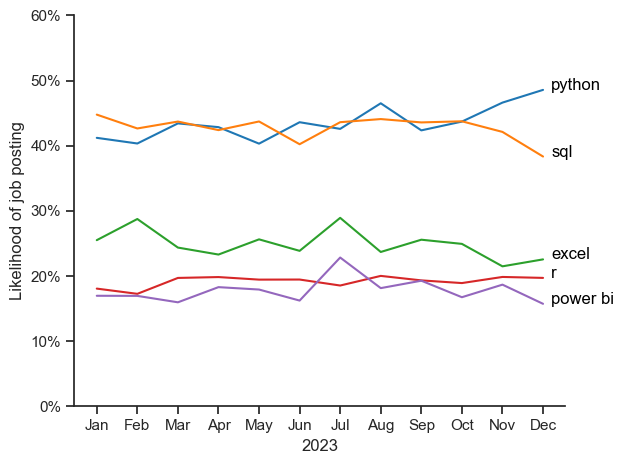

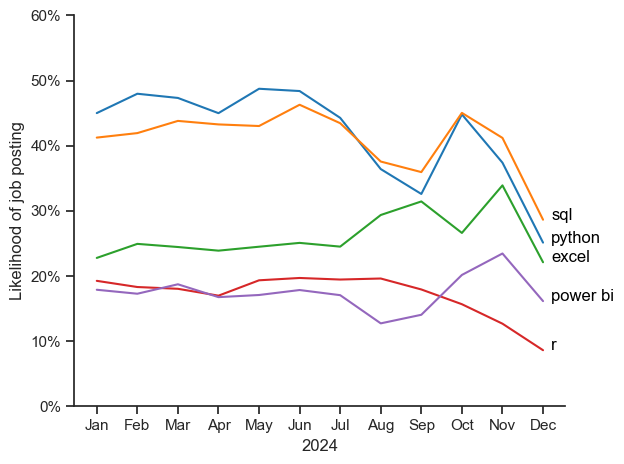

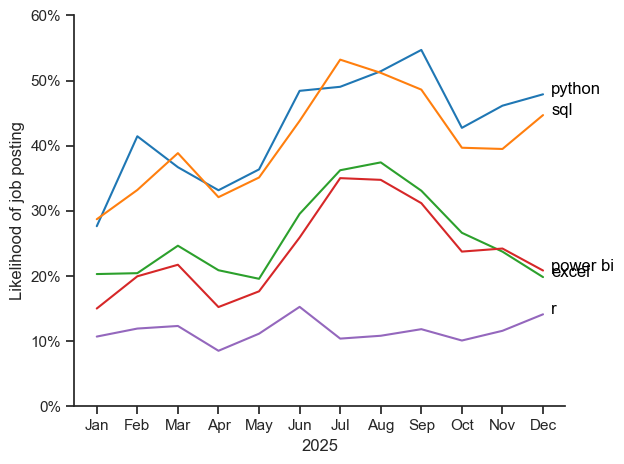

In [52]:
from matplotlib.ticker import PercentFormatter

years_name = ['2023', '2024', '2025']
years = [2023, 2024, 2025]
#establishing list to iterate through and creating new columns for months and years of postings
job_list = ['Data Analyst', 'Data Scientist', 'Machine Learning Engineer']
df['job_posted_year'] = df['job_posted_date'].dt.year
df['job_posted_month_num'] = df['job_posted_date'].dt.month

df_filtered_years = [
    df[
        (df['job_title_short'].isin(job_list))
        & (df['job_country'] == 'United Kingdom')
        & (df['job_posted_year'] == year)
    ]
    for year in years
]

df_years = [
    year_df.explode('job_skills').dropna(subset=['job_skills'])
    for year_df in df_filtered_years
]


#creating the 3 different figures for 2023, 2024, 2025
for i, (year, year_filtered, year_name) in enumerate(zip(df_years, df_filtered_years, years_name)):
  pivot_skill_counts = year.pivot_table(index = 'job_posted_month_num',
                                           columns = 'job_skills',
                                             aggfunc = 'size',
                                             fill_value = 0)
  pivot_skill_counts.loc['total'] = pivot_skill_counts.sum()
  pivot_skill_counts = pivot_skill_counts[pivot_skill_counts.loc['total'].sort_values(ascending = False).index].iloc[:, :5]
  pivot_totals = year_filtered.groupby(by = 'job_posted_month_num').size()
  pivot_skill_perc = (pivot_skill_counts.iloc[:12].div(pivot_totals/100, axis=0)).reset_index()
  # changes month number to month name
  pivot_skill_perc['job_posted_month'] = pivot_skill_perc['job_posted_month_num'].apply(lambda x: pd.to_datetime(x, format='%m').strftime('%b'))
  pivot_skill_perc = pivot_skill_perc.set_index('job_posted_month').drop(columns='job_posted_month_num')

  sns.lineplot(data = pivot_skill_perc,
                dashes = False,
                  legend = 'full',
                    palette = 'tab10'
                      )
  sns.set_theme(style = 'ticks')
  sns.despine()
  plt.ylabel('Likelihood of job posting')
  plt.xlabel(year_name)
  plt.legend().remove()
  plt.ylim(0, 60)
  for j in range(5):
    plt.text(11.2, pivot_skill_perc.iloc[-1, j], pivot_skill_perc.columns[j], color='black')
  plt.gca().yaxis.set_major_formatter(PercentFormatter(xmax=100))
  plt.tight_layout()
  plt.show()
  

    


    


